<b> Notebook for functions to compute Synergy, Redundancy and Active Information Storage.  </b>

In [1]:
import numpy as np
from idtxl.active_information_storage import ActiveInformationStorage
from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.multivariate_pid import MultivariatePID

<b>IBL data</b>

In [2]:
from tqdm.notebook import tqdm
import matplotlib as mpl
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader
from brainbox.io.spikeglx import spikeglx
from iblatlas.atlas import AllenAtlas
from brainbox.io.spikeglx import Streamer

import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd

from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path

In [4]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org", password="international", silent=False
)
ba = AllenAtlas()

In [5]:
one.load_cache(tag="Brainwidemap")

Downloading: C:\Users\debot\Downloads\ONE\openalyx.internationalbrainlab.org\Brainwidemap\tmptwdu9r4x\cache.zip Bytes: 4365971


100%|██████████| 4.163714408874512/4.163714408874512 [00:00<00:00,  6.61it/s]


In [6]:
# total of 483 sessions
sessions = one.search(
    query_type="remote", dataset="spikes.times", project="brainwide", details=True
)

In [7]:
eid = sessions[0][0]
sessionl = SessionLoader(eid=eid, one=one)
sessionl.load_trials()
pids = one.eid2pid(eid=eid)
datasets = one.list_datasets(eid, ["pykilosort/spikes.*"], qc="PASS", ignore_qc_not_set=False)
if len(datasets) == 6:
    print("QC passed")

QC passed


In [8]:
def load_spikes(pid, one, ba):
    sl = SpikeSortingLoader(pid=pid, one=one, atlas=ba)
    spikes, clusters, channels = sl.load_spike_sorting()
    clusters = sl.merge_clusters(spikes, clusters, channels)
    good_clusters = clusters["channels"][clusters["label"] == 1]
    channel_acronyms = channels["acronym"][good_clusters]

    return spikes, clusters, good_clusters, channel_acronyms

In [9]:
spikes, clusters, good_clusters, channel_acronyms = load_spikes(pids[0][0], one, ba)

In [10]:
def combine_regions(regions):
    """
    Combine all layers of cortex and the dentate gyrus molecular and granular layer
    Combine VISa and VISam into PPC
    """
    remove = ["1", "2", "3", "4", "5", "6a", "6b", "/"]
    for i, region in enumerate(regions):
        if region[:2] == "CA":
            continue
        if (region == "DG-mo") or (region == "DG-sg") or (region == "DG-po"):
            regions[i] = "DG"
        for j, char in enumerate(remove):
            regions[i] = regions[i].replace(char, "")
        if (regions[i] == "VISa") | (regions[i] == "VISam"):
            regions[i] = "PPC"
    return regions

In [11]:
BRAIN_REGIONS = ["PPC", "CA1", "DG", "LP", "PO"]

In [12]:
clusters["rep_site_acronym"] = combine_regions(clusters["acronym"])
# find valid cluster indices
cluster_idx = np.bitwise_and(
    np.isin(clusters["rep_site_acronym"], BRAIN_REGIONS), clusters["label"] == 1
)

data = {}
data["cluster_ids"] = clusters["cluster_id"][cluster_idx]
data["acronyms"] = clusters["rep_site_acronym"][cluster_idx]
spike_idx = np.isin(spikes["clusters"], data["cluster_ids"])

In [212]:
trials.columns

Index(['goCueTrigger_times', 'stimOff_times', 'goCue_times', 'response_times',
       'choice', 'stimOn_times', 'contrastLeft', 'contrastRight',
       'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume',
       'firstMovement_times', 'intervals_0', 'intervals_1'],
      dtype='object')

In [13]:
trials = sessionl.trials
correct_trials = trials["feedbackType"] == 1

# remove trials with nan stimontimes or movement times
nanStimMove = np.bitwise_or(
    np.isnan(trials["stimOn_times"]), np.isnan(trials["firstMovement_times"])
)


# left vs right stimulus
stimOn_times_start = trials["stimOn_times"][np.bitwise_and(correct_trials, ~nanStimMove)]
stimOn_times_end = stimOn_times_start + 0.1

# correct vs incorrect choice
firstMovement_times_end = trials["firstMovement_times"][~nanStimMove]
firstMovement_times_start = firstMovement_times_end - 0.1

# feedback vs no feedback representation
feedback_times_start = trials["feedback_times"][~nanStimMove]
feedback_times_end = feedback_times_start + 0.2

baseline_intervals = np.c_[stimOn_times_start - 0.2, stimOn_times_end]

In [18]:
from brainbox import singlecell

In [19]:
peths, bin_counts = singlecell.calculate_peths(
    spikes.times,
    spikes.clusters,
    clusters["cluster_id"][cluster_idx],
    align_times=stimOn_times_start,
    smoothing=False,
    bin_size=0.005,
)

In [20]:
bin_counts.shape  # trials x neurons x time

(399, 169, 140)

- split neurons by location
- synergy between neurons in different locations
  - get from BWM
  - then look at redundancy and synergy
  - some ad-hoc networks
  - 

In [99]:
# binarize bin_counts
bin_counts[bin_counts >= 1] = 1
bin_counts = np.asarray(bin_counts, dtype="int")

<b> Synergy, Redundancy and PID

In [116]:
spike_data = Data(
    bin_counts, dim_order="rps", normalise=False
)  # r-repetations, p->processes/neurons, s->samples

Adding data with properties: 169 processes, 140 samples, 399 replications
overwriting existing data


In [143]:
partial_decomposition = MultivariatePID()
settings_SxPID = {"pid_estimator": "SxPID", "lags_pid": [[3, 3], [3, 3], [3, 3]]}

In [144]:
# find out how to analyse multiple targets
sources = [[0, 1], [1, 2], [0, 2]]
targets = [2, 0, 1]

# results_SxPID = partial_decomposition.analyse_network(settings=settings_SxPID, data=data, targets=targets, sources=sources)
result = partial_decomposition.analyse_network(
    data=spike_data, settings=settings_SxPID, targets=targets, sources=sources
)


####### analysing target with index 0 from list [2, 0, 1]
+-----------+--------+------------------------+-------------------------+-------------------------+
|    RLZ    |  Atom  |          pi+           |           pi-           |            pi           |
+-----------+--------+------------------------+-------------------------+-------------------------+
| (0, 0, 0) |  {1}   |  0.013603301799820618  |   0.01345292390391637   |  0.0001503778959042485  |
|           |  {2}   | 2.6392774588172365e-05 |   2.66743404597463e-05  | -2.8156587157393635e-07 |
|           |  {12}  | 2.5003912066438953e-07 |  2.4990004220473705e-07 |  1.3907845965247792e-10 |
|           | {1}{2} |          -0.0          | -1.6017132519074588e-16 |  1.6017132519074588e-16 |
|     *     |   *    |           *            |            *            |            *            |
| (1, 0, 0) |  {1}   |    6.73543561080123    |     6.7513973563194     |  -0.015961745518169757  |
|           |  {2}   | 1.601739303257882e

In [58]:
# 1 -> unique source 1
# 2 -> unique source 2
# (1,),(2,) -> redundant
# (1,2) -> synergy

In [121]:
# now it works!!!

In [146]:
for idx in result.targets_analysed:
    print()
    print(f"Unique info T1: {result.get_single_target(idx)['avg'][(1,),][2]:1.8f}")
    print(f"Unique info T2: {result.get_single_target(idx)['avg'][(2,),][2]:1.8f}")
    print(f"Redundant info: {result.get_single_target(idx)['avg'][(1,),(2,),][2]:1.8f}")
    print(f"Synergy info: {result.get_single_target(idx)['avg'][(1,2,),][2]:1.8f}")


Unique info T1: 0.00005989
Unique info T2: 0.00000027
Redundant info: 0.00000001
Synergy info: 0.00000000

Unique info T1: 0.00000024
Unique info T2: 0.00010774
Redundant info: 0.00000001
Synergy info: 0.00000000

Unique info T1: 0.00000025
Unique info T2: 0.00000028
Redundant info: -0.00000000
Synergy info: -0.00000000


In [147]:
# iterate this network analysis over everything?
# doesn't work -_-
# we need to iterate over all sources and targets

In [148]:
import itertools

In [154]:
for idx in itertools.combinations([0, 1, 2, 5], 2):
    print(idx)

(0, 1)
(0, 2)
(0, 5)
(1, 2)
(1, 5)
(2, 5)


In [156]:
bin_counts.shape

(399, 169, 140)

In [166]:
mean_spikes = np.mean(bin_counts, axis=(0, 2))

<BarContainer object of 169 artists>

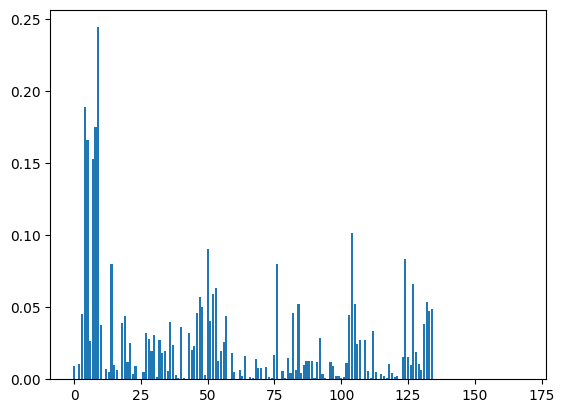

In [167]:
plt.bar(np.arange(169), mean_spikes)

In [170]:
np.median(mean_spikes)

0.006104547081990691

In [177]:
important_neurons = np.argwhere(mean_spikes > np.median(mean_spikes)).reshape(
    -1,
)

In [198]:
data["acronyms"][important_neurons]

array(['PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO',
       'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO',
       'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO',
       'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO',
       'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO',
       'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'PO', 'LP', 'LP', 'LP',
       'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP',
       'LP', 'LP', 'LP', 'LP', 'LP', 'LP', 'LP'], dtype=object)

In [19]:
def generate_sources(neurons):
    global_sources = []
    for idx in range(len(neurons)):
        mask = np.ones(neurons.shape, bool)
        mask[idx] = False
        sources = []
        for combinations in itertools.combinations(neurons[mask], 2):
            sources.append(combinations)
        global_sources.append(sources)
    return np.asarray(global_sources)

In [20]:
def get_active_neurons(spiking_data):
    mean_spikes = np.mean(spiking_data, axis=(0, 2))
    mean_firing_rate = np.mean(mean_spikes)
    important_neurons = np.argwhere(mean_spikes > mean_firing_rate).reshape(
        -1,
    )
    return important_neurons

In [21]:
trials = sessionl.trials


# remove trials with nan stimontimes or movement times
nanStimMove = np.bitwise_or(
    np.isnan(trials["stimOn_times"]), np.isnan(trials["firstMovement_times"])
)

trials = trials[~nanStimMove]
correct_trials = trials[trials["feedbackType"] == 1]


visible_trials_left = correct_trials.contrastLeft.isin([1,0.25,0.125,0.0625])
visible_trials_right = correct_trials.contrastRight.isin([1,0.25,0.125,0.0625])
visible_trials = visible_trials_left | visible_trials_right

feedback_correct = trials.feedbackType==1
feedback_incorrect = trials.feedbackType==-1

left_choice = trials.choice==1
right_choice = trials.choice==-1

# left vs right stimulus
stimOn_times_start = correct_trials["stimOn_times"]
stimOn_times_end = stimOn_times_start + 0.1

# left vs right choice
firstMovement_times_end = trials["firstMovement_times"]
firstMovement_times_start = firstMovement_times_end - 0.1

# positive feedback vs negative feedback representation
feedback_times_start = trials["feedback_times"]
feedback_times_end = feedback_times_start + 0.2






In [22]:
peths_stimulus, bin_counts_stimulus = singlecell.calculate_peths(
    spikes.times,
    spikes.clusters,
    clusters["cluster_id"][cluster_idx],
    align_times=stimOn_times_start,
    smoothing=False,
    bin_size=0.005,
    post_time=0.1,
    pre_time=0.1,
)

peths_choice, bin_counts_decision = singlecell.calculate_peths(
    spikes.times,
    spikes.clusters,
    clusters["cluster_id"][cluster_idx],
    align_times=firstMovement_times_start,
    smoothing=False,
    bin_size=0.005,
    post_time=0.1,
    pre_time=0.0,
)


peths_choice, bin_counts_feedback = singlecell.calculate_peths(
    spikes.times,
    spikes.clusters,
    clusters["cluster_id"][cluster_idx],
    align_times=feedback_times_start,
    smoothing=False,
    bin_size=0.005,
    post_time=0.2,
    pre_time=0.0,
)

In [23]:
important_neurons_stimulus = get_active_neurons(bin_counts_stimulus)
important_neurons_decision = get_active_neurons(bin_counts_decision)
important_neurons_feedback = get_active_neurons(bin_counts_feedback)

In [ ]:
# separate out trials
# stimulus, left vs right, only non-zero trials
# decision, correct vs incorrect
# feedback, also same

In [264]:
len(important_neurons_stimulus), len(important_neurons_decision), len(important_neurons_feedback)

(48, 53, 54)

In [24]:
# group before running pid stuff
# trials x neurons x time

bin_counts_stimulus_left = bin_counts_stimulus[visible_trials_left, :, :]
bin_counts_stimulus_right = bin_counts_stimulus[visible_trials_right, :, :]

bin_counts_decision_left = bin_counts_decision[left_choice, :, :]
bin_counts_decision_right = bin_counts_decision[right_choice, :, :]

bin_counts_feedback_left = bin_counts_feedback[feedback_correct, :, :]
bin_counts_feedback_right = bin_counts_feedback[feedback_incorrect, :, :]

In [25]:
bin_counts_stimulus_left = np.asarray(bin_counts_stimulus_left[:,important_neurons_stimulus,:], dtype=np.int32)
bin_counts_stimulus_right = np.asarray(bin_counts_stimulus_right[:,important_neurons_stimulus,:], dtype=np.int32)
bin_counts_decision_left = np.asarray(bin_counts_decision_left[:,important_neurons_decision,:], dtype=np.int32)
bin_counts_decision_right = np.asarray(bin_counts_decision_right[:,important_neurons_decision,:], dtype=np.int32)
bin_counts_feedback_left = np.asarray(bin_counts_feedback_left[:,important_neurons_feedback,:], dtype=np.int32)
bin_counts_feedback_right = np.asarray(bin_counts_feedback_right[:,important_neurons_feedback,:], dtype=np.int32)

In [310]:
# run only stimulus for now
 # r-repetations, p->processes/neurons, s->samples
spike_data_stim_left = Data(
    bin_counts_stimulus_left, dim_order="rps", normalise=False
) 

spike_data_stim_right = Data(
    bin_counts_stimulus_right, dim_order="rps", normalise=False
)  

Adding data with properties: 48 processes, 40 samples, 169 replications
overwriting existing data
Adding data with properties: 48 processes, 40 samples, 186 replications
overwriting existing data


In [283]:
# get bin_counts, discrete, no reason to binarize


# spike_data_stimulus = Data(
#     bin_counts_stimulus[:, important_neurons_stimulus, :], dim_order="rps", normalise=False
# )  # r-repetations, p->processes/neurons, s->samples

# spike_data_decision = Data(
#     bin_counts_decision[:, important_neurons_decision, :], dim_order="rps", normalise=False
# )  # r-repetations, p->processes/neurons, s->samples

# spike_data_feedback = Data(
#     bin_counts_feedback[:, important_neurons_feedback, :], dim_order="rps", normalise=False
# )  # r-repetations, p->processes/neurons, s->samples

In [368]:
sources = generate_sources(np.arange(len(important_neurons_stimulus)))
targets = np.arange(len(important_neurons_stimulus),dtype=np.int32)

In [420]:
# results = partial_decomposition.analyse_single_target(settings=settings_SxPID,
#                                                  data=spike_data_stim_left,
#                                                  target=0,
#                                                  sources=[1, 3,2])
# # just iterate over this
# pid_info = []
# for r in tqdm(range(len(sources[0]))):
#     S = sources[0][r]
#     partial_decomposition = MultivariatePID()
#     settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
#     result = partial_decomposition.analyse_single_target(data = spike_data_stim_left, settings=settings_SxPID,target=0, sources=S)
#     pid_info.append([result.get_single_target(0)['avg'][(1,),][2], result.get_single_target(0)['avg'][(2,),][2], result.get_single_target(0)['avg'][(1,),(2,),][2], result.get_single_target(0)['avg'][(1,2,),][2]] )
# np.log(np.mean(pid_info[:,2]/pid_info[:,3])) # redundancy/synergy

In [ ]:
# iterate over targets
PID_storage_left = np.zeros((len(targets),len(sources[0]),4))
for index,target in enumerate(targets):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index]))):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_stim_left, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_left[index, :,:] = pid_info

In [461]:
# ## PID storage for left vs right

# # PID_storage_left_stim =  PID_storage_left
# PID_storage_left = PID_storage_left_stim

In [ ]:
# iterate over targets
PID_storage_right = np.zeros((len(targets),len(sources[0]),4))
for index,target in tqdm(enumerate(targets)):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index])), leave=False):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_stim_right, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_right[index, :,:] = pid_info

In [454]:
redundancy_synergy_left = np.mean(PID_storage_left[:,:,2]/PID_storage_left[:,:,3], axis=1)
redundancy_synergy_right = np.mean(PID_storage_right[:,:,2]/PID_storage_right[:,:,3], axis=1)

In [457]:
RS_ratio_left = np.log(redundancy_synergy_left)[~np.isnan(np.log(redundancy_synergy_left))]
RS_ratio_right = np.log(redundancy_synergy_right)[~np.isnan(np.log(redundancy_synergy_right))]

C:\Users\debot\AppData\Local\Temp\ipykernel_20216\4138212359.py:1: RuntimeWarning: invalid value encountered in log
  RS_ratio_left = np.log(redundancy_synergy_left)[~np.isnan(np.log(redundancy_synergy_left))]
C:\Users\debot\AppData\Local\Temp\ipykernel_20216\4138212359.py:2: RuntimeWarning: invalid value encountered in log
  RS_ratio_right = np.log(redundancy_synergy_right)[~np.isnan(np.log(redundancy_synergy_right))]


<BarContainer object of 34 artists>

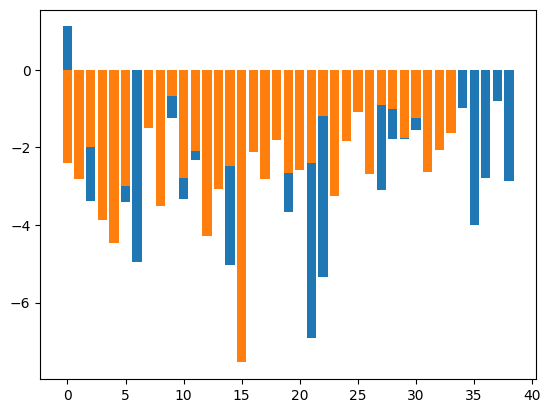

In [460]:
plt.bar(np.arange(len(RS_ratio_left)), RS_ratio_left)
plt.bar(np.arange(len(RS_ratio_right)), RS_ratio_right)

In [ ]:
## choice

# run only stimulus for now
 # r-repetations, p->processes/neurons, s->samples
spike_data_choice_left = Data(
    bin_counts_decision_left, dim_order="rps", normalise=False
) 

spike_data_choice_right = Data(
    bin_counts_decision_right, dim_order="rps", normalise=False
)  

sources = generate_sources(np.arange(len(important_neurons_decision)))
targets = np.arange(len(important_neurons_decision),dtype=np.int32)


# iterate over targets
PID_storage_left_decision = np.zeros((len(targets),len(sources[0]),4))
for index,target in enumerate(targets):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index]))):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_choice_left, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_left_decision[index, :,:] = pid_info


# iterate over targets
PID_storage_right_decision = np.zeros((len(targets),len(sources[0]),4))
for index,target in tqdm(enumerate(targets)):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index])), leave=False):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_choice_right, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_right_decision[index, :,:] = pid_info


In [ ]:
## feedback

# run only stimulus for now
 # r-repetations, p->processes/neurons, s->samples
spike_data_feedback_correct = Data(
    bin_counts_feedback_left, dim_order="rps", normalise=False
) 

spike_data_feedback_incorrect = Data(
    bin_counts_feedback_right, dim_order="rps", normalise=False
)  

sources = generate_sources(np.arange(len(important_neurons_feedback)))
targets = np.arange(len(important_neurons_feedback),dtype=np.int32)


# iterate over targets
PID_storage_feedback_correct = np.zeros((len(targets),len(sources[0]),4))
for index,target in enumerate(targets):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index])), leave=False):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_feedback_correct, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_feedback_correct[index, :,:] = pid_info


# iterate over targets


In [ ]:
# PID details
PID_storage_feedback_incorrect = np.zeros((len(targets),len(sources[0]),4))
for index,target in tqdm(enumerate(targets)):
    pid_info = []
    target = int(target)
    for r in tqdm(range(len(sources[index])), leave=False):
        S = sources[index][r]
        partial_decomposition = MultivariatePID()
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid":[3,3]}
        result = partial_decomposition.analyse_single_target(data = spike_data_feedback_incorrect, settings=settings_SxPID,target=target, sources=S)
        pid_info.append([result.get_single_target(target)['avg'][(1,),][2], result.get_single_target(target)['avg'][(2,),][2], result.get_single_target(target)['avg'][(1,),(2,),][2], result.get_single_target(target)['avg'][(1,2,),][2]])
    pid_info = np.asarray(pid_info)
    PID_storage_feedback_incorrect[index, :,:] = pid_info




In [470]:
PO_decision_neurons = np.argwhere(data['acronyms'][important_neurons_decision]=='PO').reshape(-1,)
LP_decision_neurons = np.argwhere(data['acronyms'][important_neurons_decision]=='LP').reshape(-1,)

PO_stimulus_neurons = np.argwhere(data['acronyms'][important_neurons_stimulus]=='PO').reshape(-1,)
LP_stimulus_neurons = np.argwhere(data['acronyms'][important_neurons_stimulus]=='LP').reshape(-1,)


In [474]:
PID_storage_right_PO = PID_storage_right[PO_stimulus_neurons,:,:]
PID_storage_right_LP = PID_storage_right[LP_stimulus_neurons,:,:]

PID_storage_left_PO = PID_storage_left[PO_stimulus_neurons,:,:]
PID_storage_left_LP = PID_storage_left[LP_stimulus_neurons,:,:]



PID_storage_right_decision_PO = PID_storage_right_decision[PO_decision_neurons,:,:]
PID_storage_right_decision_LP = PID_storage_right_decision[LP_decision_neurons,:,:]

PID_storage_left_decision_PO = PID_storage_left_decision[PO_decision_neurons,:,:]
PID_storage_left_decision_LP = PID_storage_left_decision[LP_decision_neurons,:,:]


Text(0.5, 0.98, 'Synergistic content in neurons')

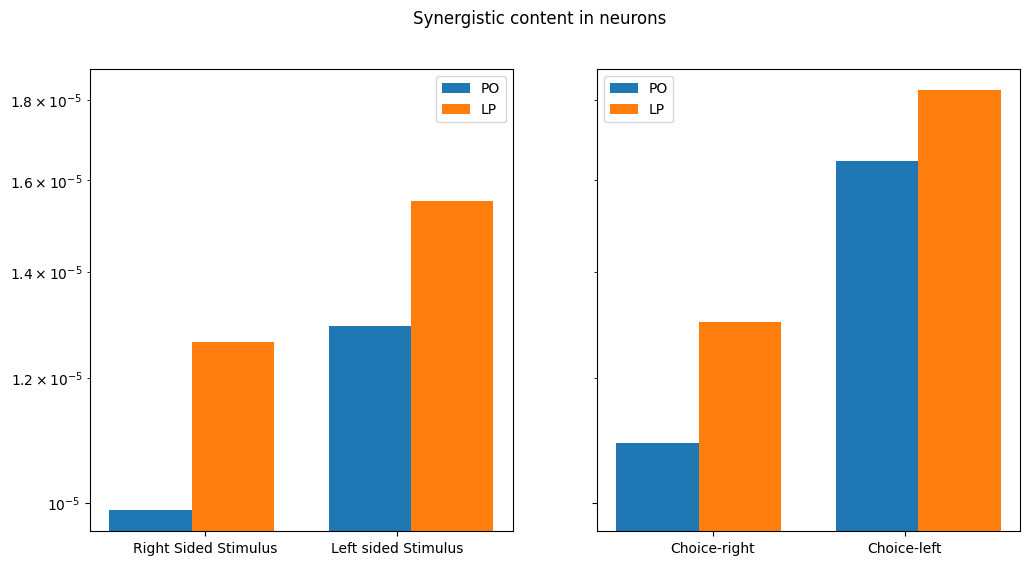

In [516]:
# synergy plots

fig, ax = plt.subplots(ncols=2, figsize=(12,6),sharey=True)

mean_synergy_right_PO = np.mean(PID_storage_right_PO[:,:,2])
mean_synergy_left_PO = np.mean(PID_storage_left_PO[:,:,2])
mean_synergy_right_LP = np.mean(PID_storage_right_LP[:,:,2])
mean_synergy_left_LP = np.mean(PID_storage_left_LP[:,:,2])

ax[0].bar([0,2],[(mean_synergy_right_PO),(mean_synergy_left_PO)],width=0.75,label='PO')
ax[0].bar([.75,2.75],[(mean_synergy_right_LP),(mean_synergy_left_LP)],width=0.75, label='LP')
ax[0].set_yscale('log')
ax[0].set_xticks([0.5,2.25],['Right Sided Stimulus','Left sided Stimulus'])
ax[0].legend()


mean_synergy_right_PO = np.mean(PID_storage_right_decision_PO[:,:,2])
mean_synergy_left_PO = np.mean(PID_storage_left_decision_PO[:,:,2])
mean_synergy_right_LP = np.mean(PID_storage_right_decision_LP[:,:,2])
mean_synergy_left_LP = np.mean(PID_storage_left_decision_LP[:,:,2])

ax[1].bar([0,2],[(mean_synergy_right_PO),(mean_synergy_left_PO)],width=0.75,label='PO')
ax[1].bar([.75,2.75],[(mean_synergy_right_LP),(mean_synergy_left_LP)],width=0.75, label='LP')
ax[1].set_yscale('log')
ax[1].set_xticks([0.5,2.25],['Choice-right','Choice-left'])
ax[1].legend()

plt.suptitle('Synergistic content in neurons')

C:\Users\debot\AppData\Local\Temp\ipykernel_20216\2652364292.py:5: RuntimeWarning: invalid value encountered in log
  mean_ratio_right_PO = np.nanmean(np.log(PID_storage_right_PO[:,:,3]/PID_storage_right_PO[:,:,2]))
C:\Users\debot\AppData\Local\Temp\ipykernel_20216\2652364292.py:6: RuntimeWarning: invalid value encountered in log
  mean_ratio_left_PO = np.nanmean(np.log(PID_storage_left_PO[:,:,3]/PID_storage_left_PO[:,:,2]))
C:\Users\debot\AppData\Local\Temp\ipykernel_20216\2652364292.py:7: RuntimeWarning: invalid value encountered in log
  mean_ratio_right_LP = np.nanmean(np.log(PID_storage_right_LP[:,:,3]/PID_storage_right_LP[:,:,2]))
C:\Users\debot\AppData\Local\Temp\ipykernel_20216\2652364292.py:8: RuntimeWarning: invalid value encountered in log
  mean_ratio_left_LP = np.nanmean(np.log(PID_storage_left_LP[:,:,3]/PID_storage_left_LP[:,:,2]))
C:\Users\debot\AppData\Local\Temp\ipykernel_20216\2652364292.py:17: RuntimeWarning: invalid value encountered in log
  mean_ratio_right_PO = n

Text(0.5, 0.98, 'Redundancy-Synergy ratio')

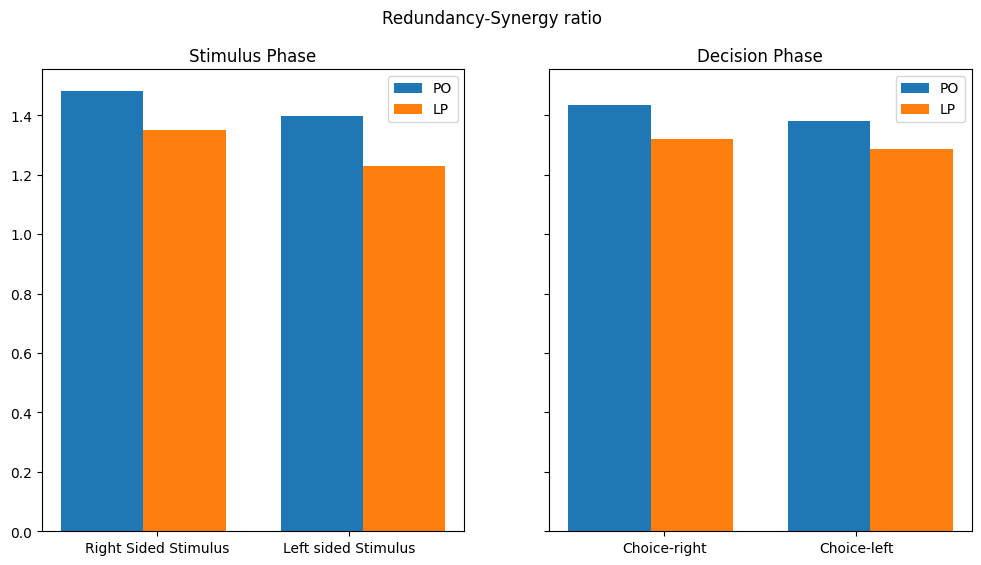

In [536]:
# Redundnacy/synergy plots

fig, ax = plt.subplots(ncols=2, figsize=(12,6),sharey=True)

mean_ratio_right_PO = np.nanmean(np.log(PID_storage_right_PO[:,:,3]/PID_storage_right_PO[:,:,2]))
mean_ratio_left_PO = np.nanmean(np.log(PID_storage_left_PO[:,:,3]/PID_storage_left_PO[:,:,2]))
mean_ratio_right_LP = np.nanmean(np.log(PID_storage_right_LP[:,:,3]/PID_storage_right_LP[:,:,2]))
mean_ratio_left_LP = np.nanmean(np.log(PID_storage_left_LP[:,:,3]/PID_storage_left_LP[:,:,2]))


ax[0].bar([0,2],[(mean_ratio_right_PO),(mean_ratio_left_PO)],width=0.75,label='PO')
ax[0].bar([.75,2.75],[(mean_ratio_right_LP),(mean_ratio_left_LP)],width=0.75, label='LP')
ax[0].set_xticks([0.5,2.25],['Right Sided Stimulus','Left sided Stimulus'])
ax[0].legend()


mean_ratio_right_PO = np.nanmean(np.log(PID_storage_right_decision_PO[:,:,3]/PID_storage_right_decision_PO[:,:,2]))
mean_ratio_left_PO = np.nanmean(np.log(PID_storage_left_decision_PO[:,:,3]/PID_storage_left_decision_PO[:,:,2]))
mean_ratio_right_LP = np.nanmean(np.log(PID_storage_right_decision_LP[:,:,3]/PID_storage_right_decision_LP[:,:,2]))
mean_ratio_left_LP = np.nanmean(np.log(PID_storage_left_decision_LP[:,:,3]/PID_storage_left_decision_LP[:,:,2]))

ax[1].bar([0,2],[(mean_ratio_right_PO),(mean_ratio_left_PO)],width=0.75,label='PO')
ax[1].bar([.75,2.75],[(mean_ratio_right_LP),(mean_ratio_left_LP)],width=0.75, label='LP')
ax[1].set_xticks([0.5,2.25],['Choice-right','Choice-left'])
ax[1].legend()

ax[0].set_title('Stimulus Phase')
ax[1].set_title('Decision Phase')

plt.suptitle('Redundancy-Synergy ratio')
